In [2]:
# %load_ext autoreload
# %autoreload 2

In [3]:
from moseplib.data import pointcloud_processing, timeseries_processing
from moseplib.data.utils import Limits

# from src.visualization.utils_3d import plot_cube, plot_sphere_interactive
from moseplib.data import config, pc_statistics
from mosep_analysis.data.config import RING_INNER, RING_OUTER, INTERIM_DATA_FOLDER, PROCESSED_DATA_FOLDER, FIGURE_FOLDER
from mosep_analysis.data import utils
from mosep_analysis.visualization.dash_apps import run_dash_3d_selection
from mosep_analysis.visualization import noise_plots

# from dask import delayed, compute
# from dask.diagnostics import ProgressBar
import pandas as pd
from pointcloudset import PointCloud
import warnings

import matplotlib.pyplot as plt
import seaborn as sns
import panel as pn

sns.set_context("paper")
sns.set_theme()
pn.extension("plotly")

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


#### Load Met Data from Bagfile

In [4]:
BAG_NAME_REFERENCE = "molisens_met_2023_08_07-15_36_45_converted"
DATA_DIR_REFERENCE = INTERIM_DATA_FOLDER / "ViF_Roof" / "data"
df_reference = timeseries_processing.load(
    DATA_DIR_REFERENCE / BAG_NAME_REFERENCE,
    "/sensing/aws/ws100_measurements",
    config.PATH_TO_LUFFT_MSGS,
    timestamp_source="msg",
)

BAG_NAME_RAIN = "molisens_met_2023_08_29-06_04_46_converted"
DATA_DIR_RAIN = INTERIM_DATA_FOLDER / "ViF_Roof" / "data"
df_rain = timeseries_processing.load(
    DATA_DIR_RAIN / BAG_NAME_RAIN,
    "/sensing/aws/ws100_measurements",
    config.PATH_TO_LUFFT_MSGS,
    timestamp_source="msg",
)

Could not import custom message types. Please check your ROS installation.
Could not import custom message types. Please check your ROS installation.


In [5]:
df_rain.precipitation["differential"].value_counts()

differential
0.00    2989
0.01     520
0.02      52
0.03      11
0.04       6
0.06       5
0.09       1
0.07       1
0.08       1
Name: count, dtype: int64

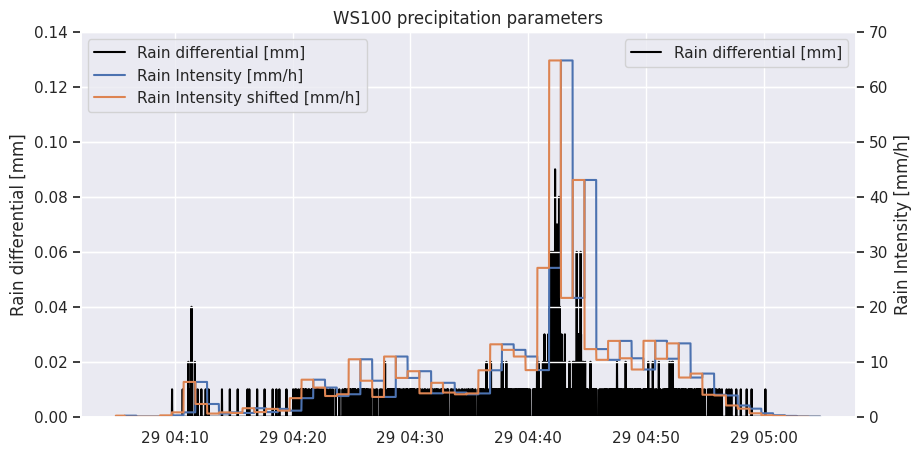

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
ax2 = ax.twinx()

# Seaborn lineplots for each series
sns.lineplot(
    x=df_rain.index, y=df_rain.precipitation["differential"], ax=ax, color="black", label="Rain differential [mm]"
)
sns.lineplot(x=df_rain.index, y=df_rain.precipitation["intensity_hour"], ax=ax2, label="Rain Intensity [mm/h]")
sns.lineplot(
    x=df_rain.index, y=df_rain.precipitation["intensity_hour"].shift(-60), ax=ax2, label="Rain Intensity shifted [mm/h]"
)

# Combine legends
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc="upper left")

ax.set_xlabel("")
ax.set_ylabel("Rain differential [mm]")
ax2.set_ylabel("Rain Intensity [mm/h]")
ax.set_title("WS100 precipitation parameters")
ax.set_ylim(0, 0.14)
ax2.set_ylim(0, 70)
plt.show()

The Lufft WS100 rain radar returns many precipitation parameters with the two most interesting for this use case being rain intensity in mm/h and differential rain intensity in mm (which refers to the variation in precipitation intensity over time). The rain intensity is only updated every minute and as also apparent from the plot, a value for rain intensity is a sum of the previous minutes differential values (and converted to mm/h from mm/min). To account for this time delay and match the rest of the measurements rain intensity is shifted by 1 minute. **Test if true**

### Load PC data

In [7]:
TOPICS = {
    "lid_pts": "/sensing/lidar/points",
    "lid_pts2": "/sensing/lidar/points2",
    "rad_pts": "/sensing/radar/points",
}

In [8]:
dataset_reference = pointcloud_processing.load_pointcloudset(
    DATA_DIR_REFERENCE, BAG_NAME_REFERENCE, topic=TOPICS["lid_pts"], verbose=True, invert_axes=["x", "y"]
)
dataset_reference_2 = pointcloud_processing.load_pointcloudset(
    DATA_DIR_REFERENCE, BAG_NAME_REFERENCE, topic=TOPICS["lid_pts2"], verbose=True, invert_axes=["x", "y"]
)
dataset_rain = pointcloud_processing.load_pointcloudset(
    DATA_DIR_RAIN, BAG_NAME_RAIN, topic=TOPICS["lid_pts"], verbose=True, invert_axes=["x", "y"]
)
dataset_rain_2 = pointcloud_processing.load_pointcloudset(
    DATA_DIR_RAIN, BAG_NAME_RAIN, topic=TOPICS["lid_pts2"], verbose=True, invert_axes=["x", "y"]
)

Searching for pointcloudset files in:
/datalocal/chg/MOLISENSext/ViF_Roof/data/pointcloudset/sensing_lidar_points/molisens_met_2023_08_07-15_36_45_conver
ted

Dataset loaded from:
/datalocal/chg/MOLISENSext/ViF_Roof/data/pointcloudset/sensing_lidar_points/molisens_met_2023_08_07-15_36_45_converted
start =    2023-08-07 13:36:48.072408
end =      2023-08-07 13:39:47.651742
duration = 0:02:59.579334
length =   1795
avg frequency =  10.00 Hz
Inverting axes: ['x', 'y']


Searching for pointcloudset files in:
/datalocal/chg/MOLISENSext/ViF_Roof/data/pointcloudset/sensing_lidar_points2/molisens_met_2023_08_07-15_36_45_conve
rted

Dataset loaded from:
/datalocal/chg/MOLISENSext/ViF_Roof/data/pointcloudset/sensing_lidar_points2/molisens_met_2023_08_07-15_36_45_converted
start =    2023-08-07 13:36:47.984902
end =      2023-08-07 13:39:47.651742
duration = 0:02:59.666840
length =   1798
avg frequency =  10.01 Hz
Inverting axes: ['x', 'y']


Searching for pointcloudset files in:
/datalocal/chg/MOLISENSext/ViF_Roof/data/pointcloudset/sensing_lidar_points/molisens_met_2023_08_29-06_04_46_conver
ted

Dataset loaded from:
/datalocal/chg/MOLISENSext/ViF_Roof/data/pointcloudset/sensing_lidar_points/molisens_met_2023_08_29-06_04_46_converted
start =    2023-08-29 04:05:19.853657
end =      2023-08-29 05:04:46.069975
duration = 0:59:26.216318
length =   35659
avg frequency =  10.00 Hz
Inverting axes: ['x', 'y']


Searching for pointcloudset files in:
/datalocal/chg/MOLISENSext/ViF_Roof/data/pointcloudset/sensing_lidar_points2/molisens_met_2023_08_29-06_04_46_conve
rted

Dataset loaded from:
/datalocal/chg/MOLISENSext/ViF_Roof/data/pointcloudset/sensing_lidar_points2/molisens_met_2023_08_29-06_04_46_converted
start =    2023-08-29 04:05:19.853657
end =      2023-08-29 05:04:46.069975
duration = 0:59:26.216318
length =   35664
avg frequency =  10.00 Hz
Inverting axes: ['x', 'y']


/home/chg/mosep-analysis/.venv/lib/python3.11/site-packages/pyntcloud/core_class.py:670: RuntimeWarning:

Mean of empty slice.

/home/chg/mosep-analysis/.venv/lib/python3.11/site-packages/numpy/core/_methods.py:121: RuntimeWarning:

invalid value encountered in divide

/home/chg/mosep-analysis/.venv/lib/python3.11/site-packages/pyntcloud/core_class.py:53: RuntimeWarning:

Mean of empty slice.

/home/chg/mosep-analysis/.venv/lib/python3.11/site-packages/numpy/core/_methods.py:121: RuntimeWarning:

invalid value encountered in divide

/home/chg/mosep-analysis/.venv/lib/python3.11/site-packages/pyntcloud/core_class.py:670: RuntimeWarning:

Mean of empty slice.

/home/chg/mosep-analysis/.venv/lib/python3.11/site-packages/numpy/core/_methods.py:121: RuntimeWarning:

invalid value encountered in divide

/home/chg/mosep-analysis/.venv/lib/python3.11/site-packages/pyntcloud/core_class.py:53: RuntimeWarning:

Mean of empty slice.

/home/chg/mosep-analysis/.venv/lib/python3.11/site-packages/nump

In [9]:
# _ = [
#     print(xn, f"{x:.2f}", yn, f"{y:.2f}", sep="\t")
#     for (xn, x), (yn, y) in zip(dataset_reference.min().iteritems(), dataset_reference.max().iteritems())
# ]

Plot an example point cloud.

In [10]:
# fig = (
#     dataset_rain[20000]
#     # .limit(dim="intensity", minvalue=0, maxvalue=500)
#     .plot(color="intensity", hover_data=["intensity"])
# )
# fig.update_layout(template="gridon", autosize=False, width=1000, height=800)
# fig

dataset_reference.animate(hover_data=True, color="intensity")

### Resample Dataset to 1s


In [11]:
rain_ds_seconds = utils.load_or_calculate(
    PROCESSED_DATA_FOLDER / f"rain_seconds_{BAG_NAME_RAIN}.pickle",
    pointcloud_processing.resample_dataset,
    ds=dataset_rain[20 * 10 :],
    resampling_period="1s",
    extra_statistics=["std", "sum"],
)

### Resample Dataset to 1min

In [12]:
rain_ds_minutes = utils.load_or_calculate(
    PROCESSED_DATA_FOLDER / f"rain_minutes_{BAG_NAME_RAIN}.pickle",
    pointcloud_processing.resample_dataset,
    ds=dataset_rain[20 * 10 :],
    resampling_period="1min",
    extra_statistics=["std", "sum"],
)

In [13]:
rain_ds_minutes_2 = utils.load_or_calculate(
    PROCESSED_DATA_FOLDER / f"rain_minutes_return2_{BAG_NAME_RAIN}.pickle",
    pointcloud_processing.resample_dataset,
    ds=dataset_rain_2[20 * 10 :],
    resampling_period="1min",
    extra_statistics=["std", "sum"],
)

## Mean point cloud

In [14]:
# # print(dataset_reference[0:10].mean())
# # print(dataset_reference[0:10].mean("pointcloud"))
# mean_cloud_ref = dataset_reference[500:600].mean("point").dropna()
# mean_cloud_rain = dataset_rain[500:600].mean("point").dropna()
# mean_cloud_ref = mean_cloud_ref.rename(columns={"x mean": "x", "y mean": "y", "z mean": "z"})
# mean_cloud_rain = mean_cloud_rain.rename(columns={"x mean": "x", "y mean": "y", "z mean": "z"})
# mean_cloud_ref.reset_index(inplace=True)
# mean_cloud_rain.reset_index(inplace=True)
# # print(mean_cloud_ref)

In [15]:
# fig = PointCloud(mean_cloud_rain, columns=["x mean", "y mean", "z mean"]).plot(
#     hover_data=True,
#     color="N",
#     width=800,
#     height=800,
#     overlay={"mean_cloud_ref": PointCloud(mean_cloud_ref, columns=["x mean", "y mean", "z mean"])},
# )
# fig

## Statistics of Noise Ring


### Isolate rings

In [16]:
# rain_ds_minutes["sum"].daskdataframe.dask
# rain_ds_minutes["sum"].daskdataframe.visualize(engine="cytoscape", optimize_graph=True)

In [17]:
app = run_dash_3d_selection(
    rain_ds_minutes["sum"].apply(RING_OUTER.apply_limits)[1].data, c_column="intensity", color_range=(0, 200)
)
app.run(jupyter_mode="external", port=8052)

Dash app running on http://127.0.0.1:8052/


### ToDos

- [ ] Make functions of plots and plot all nine variants + correlation matrix.
- [ ] Make 2D plots of all points aggregated.
- [ ] Does the second return have a benefit?
- [ ] Does the ds aggregated to seconds have a benefit when compared with differential rain intensity?
- [ ] Decide on approach



In [ ]:
# limit_intensity = Limits(i_max=1_000)
limit_n_points = Limits(n_max=20)  # this is different for minutes and seconds

exclude = {
    "ws100": Limits(x_min=7.35, x_max=7.77, y_min=-1.65, y_max=-1.39, z_min=-0.16, z_max=0.41),
    "ws501": Limits(x_min=6.086, x_max=6.43, y_min=-1.64, y_max=-1.39, z_min=-0.16, z_max=0.51),
    "wall_left": Limits(x_min=-1.0, x_max=20, y_min=3.19, y_max=6, z_min=-0.2, z_max=0.18),lude.items():
    rain_ds_minutes_ri
    "pole_6": Limits(x_min=14.09, x_max=14.38, y_min=10.35, y_max=10.75, z_min=-0.2, z_max=4.50),
}


In [49]:
# Isolate the inner and outer ring by applying limit to dataset
## Minutes
rain_ds_minutes_ring_c = rain_ds_minutes["sum"].apply(RING_INNER.apply_limits)
rain_ds_minutes_ring_w = (
    rain_ds_minutes["sum"]
    .apply(RING_OUTER.apply_limits)
    # .apply(limit_intensity.apply_limits)
    .apply(limit_n_points.apply_limits)
)
for key, value in exclude.items():
    rain_ds_minutes_ring_w = rain_ds_minutes_ring_w.apply(value.apply_exclude)


## Minutes 2
with warnings.catch_warnings(record=True):
    rain_ds_minutes_2_ring_c = rain_ds_minutes_2["sum"].apply(RING_INNER.apply_limits)
    rain_ds_minutes_2_ring_w = (
        rain_ds_minutes_2["sum"].apply(RING_OUTER.apply_limits)
        # .apply(limit_intensity.apply_limits)
        # .apply(limit_n_points.apply_limits)
    )
    for key, value in exclude.items():
        rain_ds_minutes_2_ring_w = rain_ds_minutes_2_ring_w.apply(value.apply_exclude)


## Seconds
with warnings.catch_warnings(record=True):
    rain_ds_seconds_ring_c = rain_ds_seconds["sum"].apply(RING_INNER.apply_limits)
    rain_ds_seconds_ring_w = (
        rain_ds_seconds["sum"].apply(RING_OUTER.apply_limits)
        # .apply(limit_intensity.apply_limits)
        # .apply(limit_n_points.apply_limits)
    )
    for key, value in exclude.items():
        rain_ds_seconds_ring_w = rain_ds_seconds_ring_w.apply(value.apply_exclude)

In [72]:
# Go through individual point clouds
# with warnings.catch_warnings(record=True):
#     fig = rain_ds_seconds_ring_w[35 * 60 : 37 * 60].animate(hover_data=True, color="intensity")
# fig

In [71]:
IND = 36 * 60 + 27
# RW = rain_ds_minutes_ring_w[IND]
# RC = rain_ds_minutes_ring_c[IND]
# RW = rain_ds_minutes_2_ring_w[IND]
# RC = rain_ds_minutes_2_ring_c[IND]
RW = rain_ds_seconds_ring_w[IND]
RC = rain_ds_seconds_ring_c[IND]

fig = noise_plots.plot3d(RW, RC, exclude)
fig

In [ ]:
fig.write_image(
    FIGURE_FOLDER / "rain_minutes_ring_wide_npoints_zoom_0435.svg",
)

### 2D Projections of aggregated point clouds

In [ ]:
import open3d as o3d


def test(pc):
    return pc.to_instance("OPEN3D")


fig = o3d.visualization.draw_plotly(rain_ds_minutes_ring_w.apply(test).compute())


No return type was defined in test:will not return a new dataset


In [ ]:
df = rain_ds_minutes_ring_w.agg("mean", "point")


<Axes: xlabel='x mean', ylabel='z mean'>

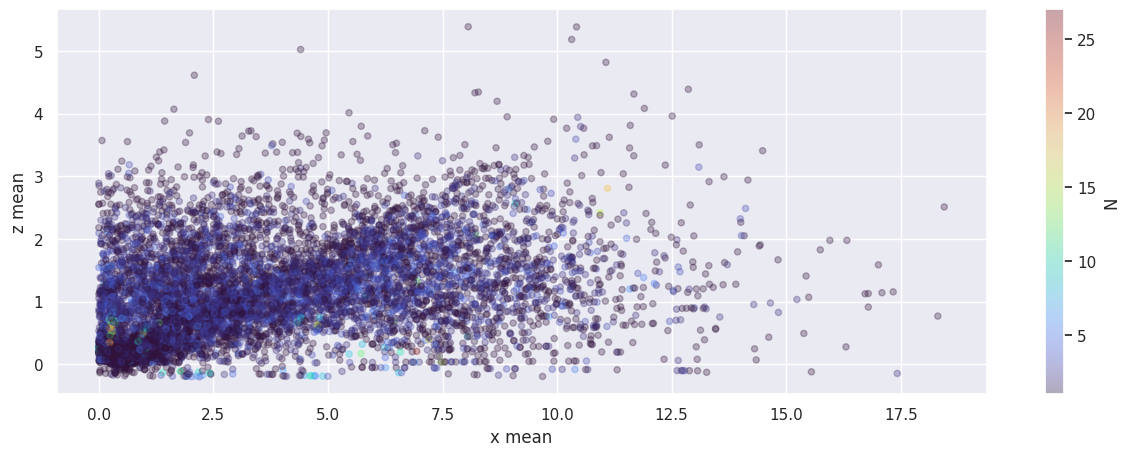

In [ ]:
df.plot(
    x="x mean", y="z mean", kind="scatter", c="N", colormap="turbo", alpha=0.3, figsize=(15, 5), backend="matplotlib"
)

In [85]:
# df_all.hvplot.scatter(x="x", y="y", datashade=True, c="N", cmap="plasma", colorbar=True, width=800, height=500)

### Result plots

In [132]:
rr_differ = df_rain.precipitation.differential  # .resample("1min").sum()
rr_tpp = df_rain.precipitation.total_precipitation_particles.resample("1min").sum()
rr_int_h = df_rain.precipitation.intensity_hour.resample("1s").mean()
# Shift to account for the AWS averaging duration
rr_int_h = rr_int_h.shift(periods=-60, freq="s")

In [76]:
n_points_ring_close_minutes = pd.concat(rain_ds_minutes_ring_c.apply(pc_statistics.n_points))
n_points_ring_wide_minutes = pd.concat(rain_ds_minutes_ring_w.apply(pc_statistics.n_points))
n_points_ring_close_minutes_2 = pd.concat(rain_ds_minutes_2_ring_c.apply(pc_statistics.n_points))
n_points_ring_wide_minutes_2 = pd.concat(rain_ds_minutes_2_ring_w.apply(pc_statistics.n_points))

In [77]:
n_points_ring_close_seconds = utils.load_or_calculate(
    PROCESSED_DATA_FOLDER / f"n_points_ring_close_seconds_{BAG_NAME_RAIN}.pickle",
    lambda: pd.concat(rain_ds_minutes_ring_c.apply(pc_statistics.n_points)),
)
n_points_ring_wide_seconds = utils.load_or_calculate(
    PROCESSED_DATA_FOLDER / f"n_points_ring_wide_seconds_{BAG_NAME_RAIN}.pickle",
    lambda: pd.concat(rain_ds_minutes_ring_w.apply(pc_statistics.n_points)),
)

In [133]:
NPRC = n_points_ring_close_seconds
NPRW = n_points_ring_wide_seconds

fig = noise_plots.temporal_development(NPRC, NPRW, rr_differ * 1000, rr_int_h)
fig

In [ ]:
fig.write_image(FIGURE_FOLDER / "rainfall_vs_noise.png", scale=5)

## Correlation

Todo:
- Check timestamps of all series in correlation matrix

In [164]:
df = pd.DataFrame(
    {
        "Noise min 0-0.6m": n_points_ring_close_minutes,
        "Noise min >0.6m": n_points_ring_wide_minutes,
        "Noise min all": n_points_ring_wide_minutes + n_points_ring_close_minutes,
        "Noise min 2 0-0.6m": n_points_ring_close_minutes_2,
        "Noise min 2 >0.6m": n_points_ring_wide_minutes_2,
        "Noise min 2 all": n_points_ring_wide_minutes_2 + n_points_ring_close_minutes_2,
        "Noise sec 0-0.6m": n_points_ring_close_seconds,
        "Noise sec >0.6m": n_points_ring_wide_seconds,
        "Noise sec all": n_points_ring_wide_seconds + n_points_ring_close_seconds,
    }
)
df["Rainfall Rate [mm/h]"] = rr_int_h
df["Rainfall Rate diff"] = rr_differ.resample("1min").sum()
df["Total Precipitation Particles"] = rr_tpp
df.corr()

,Noise min 0-0.6m,Noise min >0.6m,Noise min all,Noise min 2 0-0.6m,Noise min 2 >0.6m,Noise min 2 all,Noise sec 0-0.6m,Noise sec >0.6m,Noise sec all,Rainfall Rate [mm/h],Rainfall Rate diff,Total Precipitation Particles
Noise min 0-0.6m,1.000000,0.227794,0.882398,0.813886,0.792228,0.858019,0.871303,0.155164,0.601093,0.331224,0.397976,0.717023
Noise min >0.6m,0.227794,1.000000,0.659139,0.037843,0.289986,0.101158,0.528899,0.799285,0.758022,0.886687,0.905786,0.364970
Noise min all,0.882398,0.659139,1.000000,0.646871,0.751982,0.711551,0.929729,0.509506,0.833172,0.687951,0.745050,0.730132
Noise min 2 0-0.6m,0.813886,0.037843,0.646871,1.000000,0.684505,0.984314,0.653720,0.001637,0.386990,0.017907,0.080093,0.535689
Noise min 2 >0.6m,0.792228,0.289986,0.751982,0.684505,1.000000,0.802382,0.716776,0.219923,0.545941,0.318297,0.368960,0.448490
Noise min 2 all,0.858019,0.101158,0.711551,0.984314,0.802382,1.000000,0.709556,0.054742,0.449576,0.092209,0.154859,0.547084
Noise sec 0-0.6m,0.871303,0.528899,0.929729,0.653720,0.716776,0.709556,1.000000,0.356704,0.900525,0.432701,0.630921,0.714744
Noise sec >0.6m,0.155164,0.799285,0.509506,0.001637,0.219923,0.054742,0.356704,1.000000,0.727422,0.717330,0.815119,0.332970
Noise sec all,0.601093,0.758022,0.833172,0.386990,0.545941,0.449576,0.900525,0.727422,1.000000,0.653711,0.827103,0.607773
Rainfall Rate [mm/h],0.331224,0.886687,0.687951,0.017907,0.318297,0.092209,0.432701,0.717330,0.653711,1.000000,0.984849,0.538531


In [167]:
df = pd.DataFrame(
    {
        "Noise sec 0-0.6m": n_points_ring_close_seconds,
        "Noise sec >0.6m": n_points_ring_wide_seconds,
        "Noise sec all": n_points_ring_wide_seconds + n_points_ring_close_seconds,
    }
)
df["Rainfall Rate diff"] = rr_differ.resample("1s").mean()
df["Total Precipitation Particles"] = rr_tpp
df.corr()
# sns.heatmap(
#     df.corr(),
#     annot=True,
#     fmt=".2f",
#     cmap="coolwarm",
#     vmin=-1,
#     vmax=1,
#     cbar_kws={"label": "Correlation Coefficient"},
# )

,Noise sec 0-0.6m,Noise sec >0.6m,Noise sec all,Rainfall Rate diff,Total Precipitation Particles
Noise sec 0-0.6m,1.000000,0.356704,0.900525,0.231076,0.714744
Noise sec >0.6m,0.356704,1.000000,0.727422,0.363077,0.332970
Noise sec all,0.900525,0.727422,1.000000,0.338733,0.607773
Rainfall Rate diff,0.231076,0.363077,0.338733,1.000000,0.184998
Total Precipitation Particles,0.714744,0.332970,0.607773,0.184998,1.000000
